<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#1.Import-Dataset" data-toc-modified-id="1.Import-Dataset-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>1.Import Dataset</a></span></li></ul></div>

# Exploratory Data Analysis

## 0. Import Packages

In [16]:
#basic
import numpy as np
import pandas as pd
import os

#plot
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap

#model training
from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error, median_absolute_error
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib

#optimizer
import optuna
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
    plot_parallel_coordinate
)
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical

#regressors
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

## 1. Import Dataset

In [17]:
#get user name
user_name = os.getlogin()
print(user_name)

root


In [18]:
#reading the local csv
if user_name == 'Yushu gong':
    df = pd.read_csv("C:\\Users\\Yushu gong\\Desktop\\Albert School\\ML-SL\\Final-Project\\company_esg_financial_dataset.csv")
else:
    df = pd.read_csv(r"/Users/vivianhung/Desktop/Machine-Learning-Project/data/company_esg_financial_dataset.csv")

In [19]:
df.head(10)

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8
5,1,Company_1,Retail,Latin America,2020,567.5,6.0,384.1,2.3,55.7,65.1,28.5,73.5,42245.4,21122.7,84490.9
6,1,Company_1,Retail,Latin America,2021,604.2,5.2,479.3,6.5,55.6,66.8,25.5,74.6,44263.8,22131.9,88527.7
7,1,Company_1,Retail,Latin America,2022,593.2,4.2,248.4,-1.8,57.7,69.0,27.1,76.9,42536.3,21268.2,85072.6
8,1,Company_1,Retail,Latin America,2023,636.7,5.3,373.9,7.3,57.8,68.3,27.0,78.1,45956.3,22978.2,91912.6
9,1,Company_1,Retail,Latin America,2024,687.0,4.6,460.1,7.9,58.5,68.9,29.9,76.8,49289.1,24644.5,98578.1


In [20]:
df.columns

Index(['CompanyID', 'CompanyName', 'Industry', 'Region', 'Year', 'Revenue',
       'ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Overall',
       'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'CarbonEmissions',
       'WaterUsage', 'EnergyConsumption'],
      dtype='object')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  object 
 2   Industry           11000 non-null  object 
 3   Region             11000 non-null  object 
 4   Year               11000 non-null  int64  
 5   Revenue            11000 non-null  float64
 6   ProfitMargin       11000 non-null  float64
 7   MarketCap          11000 non-null  float64
 8   GrowthRate         10000 non-null  float64
 9   ESG_Overall        11000 non-null  float64
 10  ESG_Environmental  11000 non-null  float64
 11  ESG_Social         11000 non-null  float64
 12  ESG_Governance     11000 non-null  float64
 13  CarbonEmissions    11000 non-null  float64
 14  WaterUsage         11000 non-null  float64
 15  EnergyConsumption  11000 non-null  float64
dtypes: float64(11), int64(

In [22]:
# the data set missing the one year of growthrate data
df_missing = df[df.isnull().any(axis=1)]
print(df_missing.shape)
df_missing.head(5)

(1000, 16)


,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
11,2,Company_2,Retail,Asia,2015,2934.8,-2.9,1803.1,NaN,59.9,61.1,48.6,69.8,226554.2,113277.1,453108.3
22,3,Company_3,Transportation,Latin America,2015,259.7,5.9,140.2,NaN,25.5,3.3,41.6,31.5,183314.5,30552.4,611048.2
33,4,Company_4,Technology,Africa,2015,5036.7,21.2,23192.4,NaN,54.2,97.6,46.2,18.9,130146.6,78087.9,260293.2
44,5,Company_5,Finance,Middle East,2015,2720.9,16.1,3884.5,NaN,43.5,71.9,19.1,39.4,37894.7,18947.3,94736.7


In [23]:
#checking the unique value and time deminsion
print('The dataset contains', df['Year'].nunique(), 'years data')
print('The numbers of company in this dataset is', df['CompanyID'].nunique())

The dataset contains 11 years data
The numbers of company in this dataset is 1000


In [24]:
#for plotting and training we take year 2016-2025 for the complete set of data be used
df_all = df.sort_values(by=['CompanyID', 'Year']).copy()
print("Before dropping the 2015's, we have the df shape as", df_all.shape)

df_final = df_all.dropna().reset_index(drop=True)
print("After dropping, we got the df shape as", df_final.shape)

Before dropping the 2015's, we have the df shape as (11000, 16)
After dropping, we got the df shape as (10000, 16)


# Model Training

## 0. Context and Objective

### Context

Companies today face increasing pressure to balance **financial performance** with **sustainability goals**. 
Business leaders want to understand how operational metrics (e.g., revenue, market position, growth) and 
sustainability metrics (e.g., ESG scores, carbon emissions, resource usage) influence a company’s 
overall profitability.

To support data-driven strategic decisions, this analysis uses a multi-industry dataset containing 
financial, ESG, and environmental indicators for each company.

---

### Objective

The goal of this project is to build a predictive model that estimates a company’s **Profit Margin** using its 
financial, ESG, and environmental attributes. Specifically, the model aims to:

- Identify key drivers that influence profitability.
- Quantify the relationship between ESG performance and profit margin.
- Compare profitability patterns across different industries and regions.
- Support strategic recommendations by highlighting improvement opportunities.

This provides organizations with actionable insights to optimize performance while strengthening 
sustainability positioning.

## 1. prep for training - data cleaning and pre-setup

### 1.1 Train-Test Split

In [25]:
target = 'ProfitMargin'
categorical_cols = ['Industry', 'Region']
numeric_cols = [
    'Revenue', 'MarketCap', 'GrowthRate',
    'ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance'
]

In [26]:
# Sanity check for data leakage
corr = df_final[numeric_cols + [target]].corr()[target].sort_values(ascending=False)
print(corr)

ProfitMargin         1.000000
MarketCap            0.257612
ESG_Environmental    0.211792
Revenue              0.129420
ESG_Overall          0.083662
GrowthRate           0.060733
ESG_Social          -0.034267
ESG_Governance      -0.034477
Name: ProfitMargin, dtype: float64


In [27]:
# sanity check for multicollinearity
X_num = df_final[numeric_cols]

vif_data = pd.DataFrame()
vif_data['feature'] = X_num.columns
vif_data['VIF'] = [variance_inflation_factor(X_num.values, i)
                   for i in range(X_num.shape[1])]

print(vif_data.sort_values("VIF", ascending=False))

             feature           VIF
3        ESG_Overall  2.987386e+06
4  ESG_Environmental  4.007587e+05
5         ESG_Social  3.728103e+05
6     ESG_Governance  3.397925e+05
0            Revenue  4.094213e+00
1          MarketCap  3.701948e+00
2         GrowthRate  1.297972e+00


In [28]:
corr_matrix = df_final.corr(numeric_only=True)

# Filters only correlations above the threshold.
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # upper triangle only
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Feature1", "Feature2", "Correlation"]

# Filter strong correlations
high_corr = corr_pairs[abs(corr_pairs["Correlation"]) > 0.80] \
    .sort_values(by="Correlation", ascending=False)

print("\n Highly Correlated Feature Pairs (|corr| > 0.80):")
display(high_corr)



 Highly Correlated Feature Pairs (|corr| > 0.80):


,Feature1,Feature2,Correlation
76,CarbonEmissions,EnergyConsumption,0.997266
77,WaterUsage,EnergyConsumption,0.975123
75,CarbonEmissions,WaterUsage,0.969846
24,Revenue,MarketCap,0.835834


In [29]:
df_final["Env_Intensity_Index"] = (
    df_final["CarbonEmissions"] +
    df_final["EnergyConsumption"] +
    df_final["WaterUsage"]
) / 3

# Drop original redundant variables
df_final = df_final.drop(columns=[
    "CarbonEmissions",
    "EnergyConsumption",
    "WaterUsage"
])

In [30]:
numeric_cols.append("Env_Intensity_Index")

# train-test split
X_raw = df_final[categorical_cols + numeric_cols].copy()
y_raw = df_final[target].copy()
groups = df_final['CompanyID'].copy()

# Fill missing values
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_raw[numeric_cols] = num_imputer.fit_transform(X_raw[numeric_cols])
X_raw[categorical_cols] = cat_imputer.fit_transform(X_raw[categorical_cols])

### 1.2 Pipeline

In [31]:
numeric_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

### 1.3 model setup

In [32]:
def compute_cv_rmse(pipeline, X, y, groups, n_splits=5):
    """
    Compute GroupKFold Cross-Validated RMSE for any pipeline.
    """
    cv = GroupKFold(n_splits=n_splits)
    rmses = []

    for train_idx, test_idx in cv.split(X, y, groups):
        pipeline.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = pipeline.predict(X.iloc[test_idx])
        rmse = np.sqrt(mean_squared_error(y.iloc[test_idx], preds))
        rmses.append(rmse)

    return np.mean(rmses)

In [33]:
def tune_with_optuna(model_name, base_model, X, y, groups, n_trials=500):

    cv = GroupKFold(n_splits=5)

    def objective(trial):

        # ----- Recreate regressor for each trial -----
        if model_name == "RandomForest":
            model = RandomForestRegressor(random_state=42)

            params = {
                "n_estimators": trial.suggest_int("n_estimators", 200, 600),
                "max_depth": trial.suggest_int("max_depth", 4, 20),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
                "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            }

        elif model_name == "XGBoost":
            model = XGBRegressor(random_state=42, n_jobs=-1)

            params = {
                "n_estimators": trial.suggest_int("n_estimators", 200, 800),
                "max_depth": trial.suggest_int("max_depth", 3, 10),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "gamma": trial.suggest_float("gamma", 0, 3),
                "reg_alpha": trial.suggest_float("reg_alpha", 1e-6, 1, log=True),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-6, 1, log=True),
            }

        elif model_name == "CatBoost":
            model = CatBoostRegressor(random_state=42, verbose=0)

            params = {
                "depth": trial.suggest_int("depth", 4, 10),
                "iterations": trial.suggest_int("iterations", 200, 800),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
                "random_strength": trial.suggest_float("random_strength", 1, 20),
            }

        # ---- Build pipeline fresh for this trial ----
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("regressor", model.set_params(**params))
        ])

        # ---- CV RMSE ----
        rmses = []
        for train_idx, test_idx in cv.split(X, y, groups):
            pipeline.fit(X.iloc[train_idx], y.iloc[train_idx])
            preds = pipeline.predict(X.iloc[test_idx])
            rmse = np.sqrt(mean_squared_error(y.iloc[test_idx], preds))
            rmses.append(rmse)

        return np.mean(rmses)

    # ---- Run study ----
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    # ---- Build final model using best params ----
    best_params = study.best_params

    if model_name == "RandomForest":
        best_reg = RandomForestRegressor(random_state=42, **best_params)

    elif model_name == "XGBoost":
        best_reg = XGBRegressor(random_state=42, n_jobs=-1, **best_params)

    elif model_name == "CatBoost":
        best_reg = CatBoostRegressor(random_state=42, verbose=0, **best_params)

    # Final pipeline
    final_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", best_reg)
    ])

    final_pipeline.fit(X, y)

    return final_pipeline, study.best_value, best_params, study

In [34]:
def evaluate_model(model, X, y, groups, use_preprocessor=True, tune=False, model_name=None):

    pipeline = Pipeline([
        ("preprocessor", preprocessor if use_preprocessor else "passthrough"),
        ("regressor", model)
    ])

    def compute_metrics(model, X, y):
        preds = model.predict(X)
        r2 = r2_score(y, preds)
        rmse = np.sqrt(mean_squared_error(y, preds))
        return r2, rmse

    # Case: tuning needed
    if tune and model_name in ["RandomForest", "XGBoost", "CatBoost"]:
        tuned_model, cv_rmse, best_params, study = tune_with_optuna(
            model_name, pipeline, X, y, groups, n_trials=50
        )
        train_r2, train_rmse = compute_metrics(tuned_model, X, y)

        return tuned_model, train_r2, train_rmse, cv_rmse, study

    # Case: no tuning
    pipeline.fit(X, y)
    train_r2, train_rmse = compute_metrics(pipeline, X, y)

    return pipeline, train_r2, train_rmse, None, None

#### 1.3.1 base model selected

In [35]:
base_models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=42),
}

## 2. Model training and result

In [36]:
results_r2 = []
results_rmse = []
best_models = {}
best_studies = {}

for name, model in base_models.items():
    print(f"\n🔹 Model: {name}")

    # ===== Baseline numeric-only =====
    baseline_pipeline = Pipeline([("regressor", model)])
    baseline_cv_rmse = compute_cv_rmse(baseline_pipeline, X_raw[numeric_cols], y_raw, groups)
    
    baseline_pipeline.fit(X_raw[numeric_cols], y_raw)
    baseline_preds = baseline_pipeline.predict(X_raw[numeric_cols])
    baseline_r2 = r2_score(y_raw, baseline_preds)

    print(f"Baseline CV RMSE: {baseline_cv_rmse:.4f}")
    print(f"Baseline R²: {baseline_r2:.4f}")

    # ===== Scaler + OHE =====
    scaled_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", model)
    ])
    scaled_cv_rmse = compute_cv_rmse(scaled_pipeline, X_raw, y_raw, groups)

    scaled_pipeline.fit(X_raw, y_raw)
    scaled_preds = scaled_pipeline.predict(X_raw)
    scaled_r2 = r2_score(y_raw, scaled_preds)

    print(f"Scaler+OHE CV RMSE: {scaled_cv_rmse:.4f}")
    print(f"Scaler+OHE R²: {scaled_r2:.4f}")

    # ===== Tuned =====
    tuned_model, tuned_r2_train, tuned_rmse_train, tuned_cv_rmse, study = evaluate_model(
        model, X_raw, y_raw, groups,
        use_preprocessor=True,
        tune=True,
        model_name=name
    )

    if tuned_cv_rmse is not None:
        print(f"Tuned CV RMSE: {tuned_cv_rmse:.4f}")
    else:
        print("Tuned CV RMSE: N/A (not tuned for this model)")

    if tuned_r2_train is not None:
        print(f"Tuned R² (training): {tuned_r2_train:.4f}")
    else:
        print("Tuned R² (training): N/A (not tuned for this model)")

    # Save best model + study
    best_models[name] = tuned_model
    best_studies[name] = study

    # ===== Save RMSE table =====
    results_rmse.append({
        "Model": name,
        "Baseline_CV_RMSE": baseline_cv_rmse,
        "Scaler_OHE_CV_RMSE": scaled_cv_rmse,
        "Tuned_CV_RMSE": tuned_cv_rmse
    })

    # ===== Save R² table (NEW FULL VERSION) =====
    results_r2.append({
        "Model": name,
        "Baseline_R2": baseline_r2,
        "Scaler_OHE_R2": scaled_r2,
        "Tuned_R2": tuned_r2_train
    })

# Convert to DataFrame
results_rmse_df = pd.DataFrame(results_rmse)
results_r2_df = pd.DataFrame(results_r2)


🔹 Model: LinearRegression
Baseline CV RMSE: 8.4678
Baseline R²: 0.1247
Scaler+OHE CV RMSE: 7.8294
Scaler+OHE R²: 0.2744
Tuned CV RMSE: N/A (not tuned for this model)
Tuned R² (training): 0.2744

🔹 Model: RandomForest
Baseline CV RMSE: 7.1522
Baseline R²: 0.9486


[I 2025-11-19 23:21:30,467] A new study created in memory with name: no-name-6f0c2c13-da2d-4df7-a55b-f13184ec875b


Scaler+OHE CV RMSE: 7.0125
Scaler+OHE R²: 0.9591


Best trial: 0. Best value: 7.41807:   2%|▏         | 1/50 [00:08<06:39,  8.14s/it]

[I 2025-11-19 23:21:38,628] Trial 0 finished with value: 7.418074656785014 and parameters: {'n_estimators': 317, 'max_depth': 10, 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: 7.418074656785014.


...

[I 2025-11-19 23:57:48,305] Trial 47 finished with value: 6.944494086737896 and parameters: {'depth': 4, 'iterations': 354, 'learning_rate': 0.06591184965367605, 'l2_leaf_reg': 5.323058245936914, 'random_strength': 15.370267033392595}. Best is trial 38 with value: 6.940693624540894.


Best trial: 38. Best value: 6.94069:  98%|█████████▊| 49/50 [01:56<00:01,  1.85s/it]

[I 2025-11-19 23:57:50,859] Trial 48 finished with value: 7.183991741968174 and parameters: {'depth': 4, 'iterations': 733, 'learning_rate': 0.09916167905666892, 'l2_leaf_reg': 5.3535536079984976, 'random_strength': 15.665421286007188}. Best is trial 38 with value: 6.940693624540894.


Best trial: 38. Best value: 6.94069: 100%|██████████| 50/50 [01:57<00:00,  2.35s/it]


[I 2025-11-19 23:57:52,191] Trial 49 finished with value: 6.986864067411711 and parameters: {'depth': 4, 'iterations': 345, 'learning_rate': 0.08264432627764881, 'l2_leaf_reg': 4.246278676219775, 'random_strength': 13.51324784330483}. Best is trial 38 with value: 6.940693624540894.
Tuned CV RMSE: 6.9407
Tuned R² (training): 0.5729


In [37]:
results_rmse_df

,Model,Baseline_CV_RMSE,Scaler_OHE_CV_RMSE,Tuned_CV_RMSE
0,LinearRegression,8.467794,7.829404,NaN
1,RandomForest,7.152163,7.012492,6.832470
2,XGBoost,7.612216,7.608688,6.838622
3,CatBoost,7.395291,7.280155,6.940694


In [38]:
results_r2_df

,Model,Baseline_R2,Scaler_OHE_R2,Tuned_R2
0,LinearRegression,0.124714,0.274365,0.274365
1,RandomForest,0.948637,0.959120,0.637492
2,XGBoost,0.909798,0.929522,0.618227
3,CatBoost,0.818387,0.872394,0.572911


### 2.1 Best Model Selected

In [39]:
best_row = results_rmse_df.loc[results_rmse_df["Tuned_CV_RMSE"].idxmin()]
best_model_name = best_row["Model"]

best_model = best_models[best_model_name]
best_study = best_studies.get(best_model_name)

### 2.2 Optuna plt

In [40]:
if best_study is None:
    print("⚠️ no Optuna Tuning records")
else:
    plt.figure(figsize=(16,5))
    plot_param_importances(best_study)
    #plt.title(f"Optuna Param Importance")
    plt.show()

<Figure size 1600x500 with 0 Axes>

/var/folders/_z/cd5g6gkj7h5ccbw0cjnj65y80000gn/T/ipykernel_98090/4248447653.py:7: ExperimentalWarning:

optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.



<Figure size 1600x500 with 0 Axes>

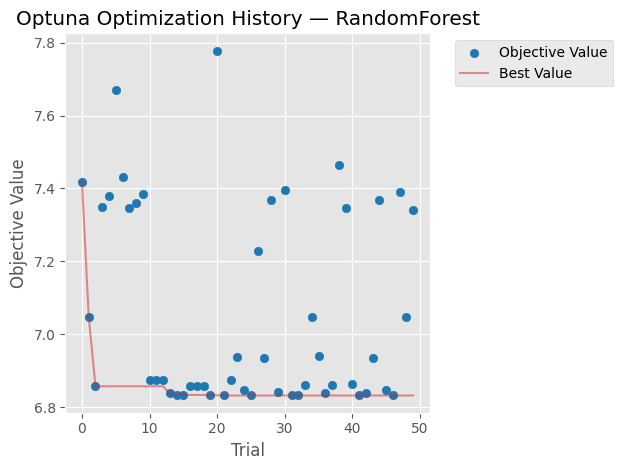

In [41]:
from optuna.visualization.matplotlib import plot_optimization_history

if best_study is None:
    print("⚠️ no Optuna Tuning record")
else:
    plt.figure(figsize=(16,5))
    plot_optimization_history(best_study)
    plt.title(f"Optuna Optimization History — {best_model_name}")
    plt.show()


### 2.3 Featrue importance

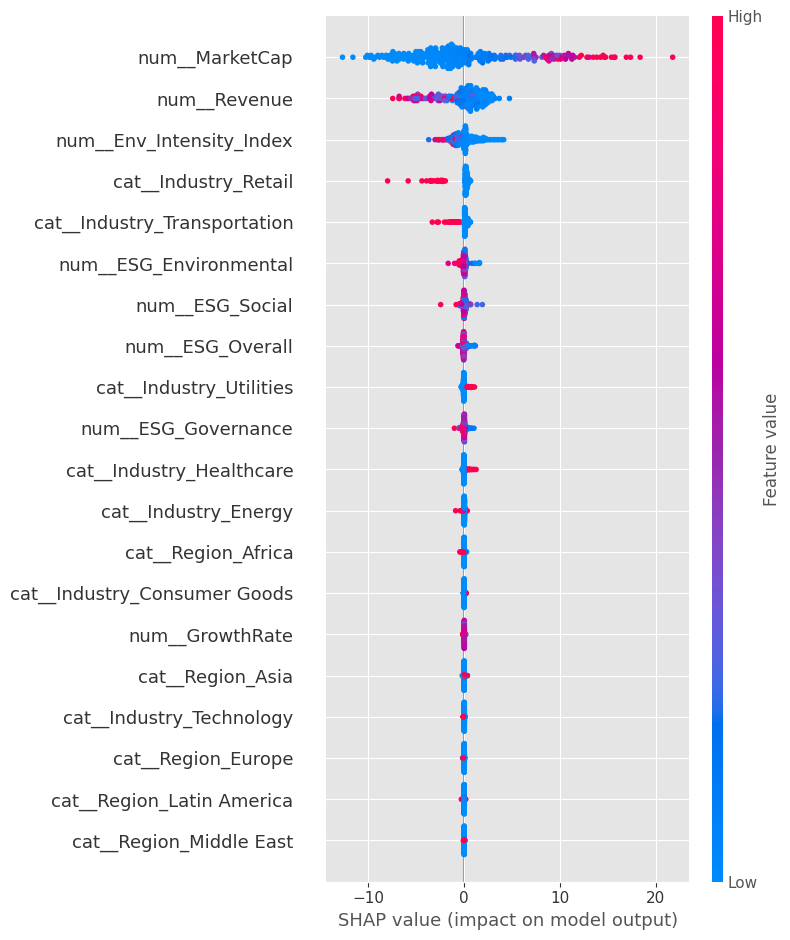

In [42]:
X_sample = X_raw.sample(300, random_state=42)

try:
    reg = best_model.named_steps["regressor"]
    X_trans = best_model.named_steps["preprocessor"].transform(X_sample)
    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
except:
    reg = best_model
    X_trans = X_sample
    feature_names = X_raw.columns

is_tree = any(keyword in str(type(reg)) for keyword in [
    "XGB", "LGBM", "CatBoost", "Forest", "Tree", "GradientBoosting"
])

if is_tree:
    explainer = shap.TreeExplainer(reg)
    shap_values = explainer(X_trans)
else:
    print("⚠️ 非 tree 模型，使用 KernelExplainer（較慢）")
    explainer = shap.KernelExplainer(reg.predict, X_trans[:50])
    shap_values = explainer.shap_values(X_trans[:200])

# --- Summary Plot ---
shap.summary_plot(shap_values, X_trans, feature_names=feature_names, show=True)


## 3. Strategy

In [43]:
# ================================================================
# 1. USER INPUT SYSTEM
# ================================================================

def convert_user_threshold(user_score):
    """Convert scale 1–10 → percentile 0.10–0.90."""
    return 0.1 + (user_score - 1) * (0.8 / 9)


def ask_sustainability_dimension():
    print("\n🌱 Which sustainability dimension do you want to focus on?\n")
    print("1. ESG Overall Score")
    print("2. ESG Environmental Score")
    print("3. ESG Social Score")
    print("4. ESG Governance Score")

    mapping = {
        1: "ESG_Overall",
        2: "ESG_Environmental",
        3: "ESG_Social",
        4: "ESG_Governance",
    }

    while True:
        try:
            choice = int(input("\nSelect a number (1–4): → "))
            if 1 <= choice <= 4:
                return mapping[choice]
            else:
                print("❗ Please enter a number between 1 and 4.")
        except:
            print("❗ Invalid input. Please enter a number between 1 and 4.")


def ask_user_preference():
    print("\n🌱 Sustainability Priority Level (1–10)")
    print("1  = I prioritize profit only")
    print("10 = I want the strongest sustainability performance")

    while True:
        try:
            score = int(input("\nHow much do you care (1–10)? → "))
            if 1 <= score <= 10:
                return score
            else:
                print("❗ Please enter a number between 1 and 10.")
        except:
            print("❗ Invalid input. Enter a number between 1 and 10.")


# ================================================================
# 2. PORTFOLIO FILTER + OPTIMIZATION
# ================================================================

def filter_by_environment(df, user_score, e_col):
    percentile = convert_user_threshold(user_score)

    # If lower is better → invert threshold
    if e_col in ["CarbonEmissions", "EnergyConsumption", "WaterUsage"]:
        threshold_value = df[e_col].quantile(1 - percentile)
        df_filtered = df[df[e_col] <= threshold_value].copy()
    else:
        threshold_value = df[e_col].quantile(percentile)
        df_filtered = df[df[e_col] >= threshold_value].copy()

    return df_filtered, threshold_value


def build_portfolio(df, user_score, e_col, top_n=3, alpha=0.4, beta=0.6):

    df_filtered, threshold_value = filter_by_environment(df, user_score, e_col)
    df_filtered = df_filtered.copy()

    print(f"\n🌱 Focusing on: {e_col}")
    print(f"📊 Threshold applied: {threshold_value:.2f}")
    print(f"📉 Companies remaining: {len(df_filtered)} / {len(df)}")

    if len(df_filtered) == 0:
        print("❗ No companies meet this sustainability threshold.")
        return pd.DataFrame()

    # Safe normalization for predicted profit
    pmin, pmax = df_filtered["predicted_profit"].min(), df_filtered["predicted_profit"].max()
    prange = (pmax - pmin) if (pmax - pmin) != 0 else 1
    df_filtered["profit_norm"] = (df_filtered["predicted_profit"] - pmin) / prange

    # Safe normalization for sustainability dimension
    emin, emax = df_filtered[e_col].min(), df_filtered[e_col].max()
    erange = (emax - emin) if (emax - emin) != 0 else 1
    df_filtered["escore_norm"] = (df_filtered[e_col] - emin) / erange

    # Composite score
    df_filtered["portfolio_score"] = (
        alpha * df_filtered["profit_norm"] + beta * df_filtered["escore_norm"]
    )

    # Top N per industry
    portfolio = (
        df_filtered
        .sort_values(["Industry", "portfolio_score"], ascending=[True, False])
        .groupby("Industry")
        .head(top_n)
        .reset_index(drop=True)
    )

    return portfolio


# ================================================================
# 3. AGGREGATION — ONE ROW PER COMPANY (2016–2025 AVERAGE)
# ================================================================

def aggregate_company_data(df, company_ids, company_col="CompanyID"):
    """Return ONE row per company with averaged numeric values."""
    subset = df[df[company_col].isin(company_ids)].copy()

    # Identify numeric & categorical columns
    numeric_cols = subset.select_dtypes(include=["int64", "float64"]).columns
    categorical_cols = subset.select_dtypes(include=["object"]).columns

    # Remove CompanyID from numeric columns if present
    numeric_cols = numeric_cols.drop(company_col) if company_col in numeric_cols else numeric_cols

    # Group numeric → mean
    df_numeric = subset.groupby(company_col)[numeric_cols].mean()

    # Group categorical → mode
    df_categorical = subset.groupby(company_col)[categorical_cols].agg(lambda x: x.mode().iloc[0])

    # Merge back
    df_final = df_numeric.merge(df_categorical, left_index=True, right_index=True)

    # Prevent inserting CompanyID twice
    return df_final.reset_index(drop=False)



# ================================================================
# 4. RUN PIPELINE
# ================================================================

# Add predictions to dataset
df_final["predicted_profit"] = best_model.predict(X_raw)

# Step 1: Ask sustainability dimension
chosen_dimension = ask_sustainability_dimension()

# Step 2: Ask sustainability strength
user_score = ask_user_preference()

# Step 3: Build portfolio (raw rows)
portfolio_raw = build_portfolio(
    df_final,
    user_score=user_score,
    e_col=chosen_dimension,
    top_n=3
)

# Step 4: Collapse to one row per company
portfolio_final = aggregate_company_data(df_final, portfolio_raw["CompanyID"])
portfolio_final = portfolio_final.drop(columns=['Year', 'CompanyName'])

print("\n🎯 Recommended Portfolio (Averaged 2016–2025):")
display(portfolio_final)


🌱 Which sustainability dimension do you want to focus on?

1. ESG Overall Score
2. ESG Environmental Score
3. ESG Social Score
4. ESG Governance Score

🌱 Sustainability Priority Level (1–10)
1  = I prioritize profit only
10 = I want the strongest sustainability performance

🌱 Focusing on: ESG_Environmental
📊 Threshold applied: 52.50
📉 Companies remaining: 5451 / 10000

🎯 Recommended Portfolio (Averaged 2016–2025):


,CompanyID,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,Env_Intensity_Index,predicted_profit,Industry,Region
0,66,1676.27,23.38,6236.59,4.44,61.56,94.29,56.09,34.30,4.382432e+05,16.571012,Consumer Goods,Middle East
1,152,25872.22,30.33,189767.48,-1.71,64.60,96.24,68.85,28.75,8.185495e+05,27.326014,Technology,Latin America
2,157,5136.19,17.65,17160.78,3.44,91.24,91.20,95.54,87.00,1.387571e+06,15.620326,Consumer Goods,Europe
3,168,2463.08,32.39,13502.32,2.23,79.80,94.04,47.86,97.51,1.770140e+05,25.115494,Healthcare,North America
4,280,601.48,25.41,2212.40,-0.87,50.09,93.94,40.87,15.46,2.954381e+05,16.544654,Transportation,Africa
5,324,3270.68,13.41,5682.75,4.11,64.65,90.68,32.23,71.02,6.929319e+06,10.982258,Energy,Middle East
6,335,361.87,10.56,435.85,-1.53,76.28,99.48,94.24,35.14,5.649909e+05,8.825067,Utilities,Latin America
7,337,4181.44,22.64,15156.27,11.17,68.85,96.74,70.95,38.82,5.789304e+04,18.796780,Finance,Africa
8,353,3562.23,28.62,15154.50,16.49,94.12,99.55,86.23,96.58,4.793175e+04,20.759863,Finance,Europe
9,425,4566.06,14.32,11814.51,2.52,62.92,93.59,44.93,50.20,1.200874e+06,15.964309,Consumer Goods,Middle East
